## 라이브러리 설치 및 임포트

In [1]:
!pip install nptdms
import gdown
import zipfile
import os
from nptdms import TdmsFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
from IPython.display import display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nptdms: filename=nptdms-1.10.0-py3-none-any.whl size=108456 sha256=35e4beb6beef132fb6a8404bf35d5f6bca39464883f3e015cd52001d7260ee5f
  Stored in directory: /root/.cache/pip/wheels/1b/4b/17/21e8b03b37ea51ce7ec9f5570cdf0decca93f537d61c06880f
Successfully built nptdms


# 구글드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd drive/MyDrive/Bearing data

/content/drive/MyDrive/Bearing data


## 아래 코드 실행 후 위에 런타임 항목에서 세션 다시시작 누르고 다시 아래코드빼고 다 돌리면 됨

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (20.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126102 files and direc

In [ ]:
# 한글폰트 쓰려면 이거는 무조건 실행

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 구글 드라이브에 저장된 파일 링크로 데이터 불러오기

In [ ]:
# https://drive.google.com/file/d/1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE/view?usp=sharing

# 공유 링크에서 파일 ID 추출
file_id = '1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE'

# 저장할 zip 파일 이름
zip_path = 'train.zip'
extract_dir = 'data'

# 다운로드
gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"압축 해제 완료: {extract_dir}/")

Downloading...
From (original): https://drive.google.com/uc?id=1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE
From (redirected): https://drive.google.com/uc?id=1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE&confirm=t&uuid=1826989d-f1f8-4e23-a369-3d12048fec41
To: /content/train.zip
100%|██████████| 4.19G/4.19G [00:45<00:00, 93.0MB/s]


# 아래 코드 실행하기 위해 필요한 함수

In [ ]:
# 데이터 처리
def load_tdms_file(file_path):
    tdms_file = TdmsFile.read(file_path)

    # group_name_vibration: {CH1, CH2, CH3, CH4} 데이터, group_name_operation: {Torque[Nm], TC SP Front[℃], TC SP Rear[℃]} 데이터
    group_name_vibration = tdms_file.groups()[0].name
    group_name_operation = tdms_file.groups()[1].name

    vib_channels = tdms_file[group_name_vibration].channels()
    vib_data = {ch.name: ch.data for ch in vib_channels}

    operation_channels = tdms_file[group_name_operation].channels()
    operation_data = {ch.name: ch.data for ch in operation_channels}

    return vib_data , operation_data


# 데이터 프레임 형태로 변환
def create_time_indexed_dataframe(vib_data, operation_data, fs=25600):
    """
    vib_data: {'CH1': np.array, 'CH2': np.array, ...}
    operation_data: {'Torque[Nm]': np.array([val]), ...}
    fs: sampling frequency in Hz (default: 25.6 kHz)
    """

    # 데이터 길이 (CH1 기준으로 동일하다고 가정)
    N = len(vib_data["CH1"])

    # 시간 인덱스 생성
    time_index = np.arange(N) / fs

    # 진동 데이터프레임 구성
    df = pd.DataFrame(vib_data, index=time_index)
    df.index.name = "Time (s)"

    # 상태값 broadcast (모든 row에 동일하게 삽입)
    for key, val in operation_data.items():
        clean_key = key.strip()  # 공백 제거 (예: '   TC SP Front[℃]')
        df[clean_key] = val[0]

    return df



# raw 데이터 시각화
def plot_vibration_channels(df, channels=["CH1", "CH2", "CH3", "CH4"]):
    """
    시간 인덱스를 가진 df에서 지정된 채널들을 시간에 따라 시각화
    """
    plt.figure(figsize=(14, 8))

    for i, ch in enumerate(channels, 1):
        plt.subplot(len(channels), 1, i)
        plt.plot(df.index, df[ch], linewidth=0.5)
        plt.title(f"{ch} vs Time", fontsize=12)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


# window 사이즈 설정 후 rms 처리하고 시각화
def plot_rms_over_time(df, channels=["CH1", "CH2", "CH3", "CH4"], window_size=1000, fs=25600):
    """
    지정된 채널들의 RMS를 window 단위로 계산 후 시각화
    """
    plt.figure(figsize=(14, 8))

    for i, ch in enumerate(channels, 1):
        signal = df[ch].values
        n = len(signal)

        # RMS 계산
        rms_values = [
            np.sqrt(np.mean(signal[j:j+window_size]**2))
            for j in range(0, n - window_size + 1, window_size)
        ]

        # 시간 인덱스 생성 (윈도우 중심)
        time_index = np.arange(len(rms_values)) * (window_size / fs)

        # 플롯
        plt.subplot(len(channels), 1, i)
        plt.plot(time_index, rms_values, linewidth=0.8)
        plt.title(f"RMS of {ch} (window={window_size})", fontsize=12)
        plt.xlabel("Time (s)")
        plt.ylabel("RMS Amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()



# 파일 선택 콤보박스로 하게 해주는 함수
def select_tdms_file():
    global data_dir  # 전역으로 저장

    root_folder = "data"

    # 폴더 리스트 가져오기
    train_folders = sorted([
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f))
    ])

    # 폴더 선택 드롭다운
    folder_dropdown = widgets.Dropdown(
        options=train_folders,
        description="폴더 선택:",
        layout=widgets.Layout(width='50%')
    )

    # 파일 선택 드롭다운
    file_dropdown = widgets.Dropdown(
        options=[],
        description="파일 선택:",
        layout=widgets.Layout(width='60%')
    )

    display(folder_dropdown)
    display(file_dropdown)

    # 폴더 선택 시 파일 목록 갱신
    def update_file_list(change):
        selected_folder = change.new
        full_path = os.path.join(root_folder, selected_folder)
        tdms_files = sorted([
            f for f in os.listdir(full_path) if f.endswith(".tdms")
        ])
        file_dropdown.options = tdms_files
        if tdms_files:
            file_dropdown.value = tdms_files[0]

    folder_dropdown.observe(update_file_list, names='value')

    # 파일 선택 시 data_dir 저장
    def on_file_selected(change):
        selected_folder = folder_dropdown.value
        global data_dir
        data_dir = os.path.join(root_folder, selected_folder, change.new)
        print(f"✅ 선택된 파일 경로가 data_dir에 저장되었습니다:\n{data_dir}")

    file_dropdown.observe(on_file_selected, names='value')

    # 초기 트리거
    folder_dropdown.value = train_folders[0]

# 커스텀 데이터 셋

In [ ]:
from torch.utils.data import Dataset
import torch
import os
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch
import math

class BearingDatasetFromMeta(Dataset):
    def __init__(self, meta_df, base_dir, load_function):
        """
        meta_df: 파일 이름과 RUL 정보가 포함된 DataFrame
        base_dir: base 폴더 경로 (예: "data/Train Set")
        load_function: 사용자 정의 파일 로딩 함수 (file_path → DataFrame)
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.base_dir = base_dir
        self.load_function = load_function

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]

        # 전체 경로 조합: base_dir / train_set / file
        file_path = os.path.join(self.base_dir, row['train_set'], row['file'])

        # 시계열 데이터 로드 (shape: [256000, 7])
        vib_data, operation_data = self.load_function(file_path)
        df = create_time_indexed_dataframe(vib_data, operation_data)
        data = df.values.astype('float32')

        X = data[:, :]  # 시계열 입력 (전체 7개 채널)
        y = row['RUL_seconds']  # 메타데이터에서 직접 수명 타겟 추출

        X_tensor = torch.tensor(X).contiguous()
        y_tensor = torch.tensor([y], dtype=torch.float32)

        return X_tensor, y_tensor

In [ ]:
# 데이터 샘플링
train_meta = pd.read_csv("train_meta.csv")  # 또는 rul_result
base_dir = "data/Train Set"
dataset = BearingDatasetFromMeta(train_meta, base_dir, load_tdms_file)

In [ ]:
# 데이터 로딩
train_set, val_set = random_split(dataset, [int(0.8*len(dataset)), len(dataset) - int(0.8*len(dataset))],
                                  generator=torch.Generator().manual_seed(42)) # train / val  분류 고정
train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

In [ ]:
# 학습시 반복 수: 데이터 수 / 배치 사이즈
print(f"🔹 총 학습 배치 수: {len(train_loader)}")
print(f"🔹 총 검증 배치 수: {len(val_loader)}")
# 샘플 하나 보기
x_sample, y_sample = dataset[93]
# 텐서 크기 및 값 확인
print(f"✅ X 샘플 shape: {x_sample.shape}")     # 기대: torch.Size([256000, 7])
print(f"✅ y 샘플 값: {y_sample.item()}")         # 기대: RUL 값 (float)

🔹 총 학습 배치 수: 983
🔹 총 검증 배치 수: 246
✅ X 샘플 shape: torch.Size([256000, 7])
✅ y 샘플 값: 10.0


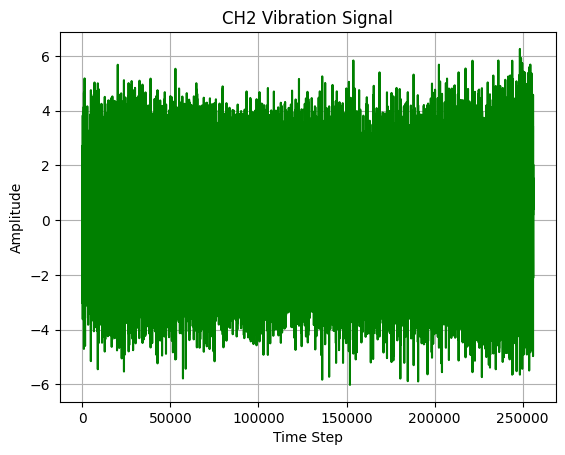

In [ ]:
# 시계열 시각화
ch1 = x_sample[:, 1].numpy() # 1,2,3,4
plt.plot(ch1, color='green')
plt.title("CH2 Vibration Signal")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 학습 때 필요한 함수 정의

---
- loss function
- 평가 지표 for monitoring
- train 함수
- val 함수


In [ ]:
from tqdm import tqdm

def asymmetric_mse(predicted, actual, penalty=3.0):
    error = actual - predicted
    weight = torch.where(predicted > actual, penalty, 1.0)
    return (weight * error**2).mean()


def compute_rul_score(predicted, actual):
    """
    predicted: tensor of shape (N, 1)
    actual:    tensor of shape (N, 1)
    Returns: final score (float)
    """
    predicted = predicted.view(-1)
    actual = actual.view(-1)
    eps = 1e-6

    er = 100 * (actual - predicted) / (actual + eps)

    # 조건별 점수 계산
    score = torch.where(
        er <= 0,
        torch.exp(-math.log(0.5) * (er / 20)),
        torch.exp(+math.log(0.5) * (er / 50))
    )

    return score.mean().item()  # 스칼라 값 반환


def evaluate_model(model, val_loader, device="cpu"):
    model.eval()
    all_scores = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(x_batch)
            batch_score = compute_rul_score(pred, y_batch)
            all_scores.append(batch_score)

    final_score = sum(all_scores) / len(all_scores)
    print(f"\n✅ 전체 검증 데이터에 대한 최종 평균 A_RUL Score: {final_score:.4f}")
    return final_score





def train_model(model, train_loader, val_loader, optimizer, n_epochs=20, device="cpu"):
    model.to(device)
    criterion = asymmetric_mse

    best_val_score = -float("inf")
    best_model_state = None

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0.0

        print(f"\n🔁 Epoch {epoch}/{n_epochs}")
        for x_batch, y_batch in tqdm(train_loader, desc=f"🟢 Training"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)

        # 검증
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device)

                pred_val = model(x_val)
                loss_val = criterion(pred_val, y_val)
                val_loss += loss_val.item()

        val_loss /= len(val_loader)
        val_score = evaluate_model(model, val_loader, device=device)

        print(f"📊 Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | A_RUL Score: {val_score:.4f}")

        if val_score > best_val_score:
            best_val_score = val_score
            best_model_state = model.state_dict()
            print("✅ 새로운 최고 모델 저장됨!")

    print(f"\n🎉 학습 완료! 최고 검증 점수: {best_val_score:.4f}")
    model.load_state_dict(best_model_state)

    return model


# 모델링

---
1. CNN-LSTM
2. LSTM
3. N-Linear


## CNN-LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNLSTM(nn.Module):
    def __init__(self, input_channels=7):
        super(CNNLSTM, self).__init__()

        # Conv1D: 입력 시계열에서 지역적인 특징 추출 (예: 진동의 작은 급변 패턴 감지)
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=5)

        # MaxPooling: 시계열 길이 줄이면서 중요한 특징만 남김 (계산 효율 향상)
        self.pool = nn.MaxPool1d(kernel_size=2)

        # LSTM: 지역 특징 시퀀스를 받아서 시간적 패턴(추세, 변화 등)을 학습
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, batch_first=True)

        # FC Layer: 마지막 LSTM 출력을 받아서 RUL 회귀값으로 변환
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # RUL 회귀
        )

    def forward(self, x):
        # x: (batch, time_steps, channels)
        x = x.permute(0, 2, 1).contiguous()        # → (batch, channels, time_steps) for Conv1D
        x = F.relu(self.conv1(x))    # Conv + ReLU
        x = self.pool(x)             # Pooling
        x = x.permute(0, 2, 1).contiguous()       # → (batch, time, features) for LSTM
        x, _ = self.lstm(x)          # LSTM sequence output
        x = x[:, -1, :]              # 마지막 시점의 hidden state
        return self.fc(x)            # FC 회귀 결과 (RUL)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PureLSTM(nn.Module):
    def __init__(self, input_channels=7):
        super(PureLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_channels,  # feature 수 = 7 (CH1~CH4, 온도, 토크 등)
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # RUL 예측
        )

    def forward(self, x):
        # x: (batch, time, features=7)
        x, _ = self.lstm(x)      # → x: (batch, time, 64)
        x = x[:, -1, :]          # 마지막 time step의 hidden state만 사용
        return self.fc(x)        # → (batch, 1)


# 모델 학습 설정

In [ ]:
# 설정
model = CNNLSTM(input_channels=7) # 모델 인자 설정

# 학습 파라미터 설정
n_epochs = 30
learning_rate = 1e-3
#device = "cuda" if torch.cuda.is_available() else "cpu"
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# 학습 시작
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    n_epochs=n_epochs,
    #device=device
)

# validation(실제 추론) 파일 다운로드

In [ ]:
# https://drive.google.com/file/d/1OEaU5cShJpNNPiVojiNv1h5iJag05hPG/view?usp=sharing

# 공유 링크에서 파일 ID 추출
file_id = '1OEaU5cShJpNNPiVojiNv1h5iJag05hPG'

# 저장할 zip 파일 이름
zip_path = 'val.zip'
extract_dir = 'data'

# 다운로드
gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"압축 해제 완료: {extract_dir}/")

Downloading...
From (original): https://drive.google.com/uc?id=1OEaU5cShJpNNPiVojiNv1h5iJag05hPG
From (redirected): https://drive.google.com/uc?id=1OEaU5cShJpNNPiVojiNv1h5iJag05hPG&confirm=t&uuid=e8e52ea7-d1b0-4407-9344-f0a04472255d
To: /content/val.zip
100%|██████████| 1.05G/1.05G [00:14<00:00, 71.1MB/s]


압축 해제 완료: data/


# 왼쪽 파일 경로 설명

---

왼쪽 데이터 경로를 보면 data 파일 누르고 Train Set 들어가면 Train 1 ~ Train 8 이 보인다.

이는, 베어링 샘플 실험 총 8번한거고 Train 1 안에는 여러개의 tdms 파일이 있는데 이거는 10분간격으로 10초동안 취득한 데이터 파일을 나눠서 저장한 것이다.

즉 우리 베어링 실험 기준으로는 lvm 파일이 나누어진건 용량으로 분리되는거지만 여기 경우는 10분간격으로 10초동안 수집한 데이터 즉, 하나의 파일은 10초동안 취득한 데이터이고 파일 간에 시간 차이는 약 9분 50초인 것!

In [ ]:
# 코드를 실행하면 콤보박스로 베어링 샘플을 먼저 선택한 후 해당 샘플의 tdms 파일(10초동안의 취득한 데이터)을 선택할 수 있다.
select_tdms_file()

Dropdown(description='폴더 선택:', layout=Layout(width='50%'), options=('Train Set', 'Validation1', 'Validation2',…

Dropdown(description='파일 선택:', layout=Layout(width='60%'), options=(), value=None)

✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation1/modified_KIMM Simulator_KIMM Bearing Test_20160320041739.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation1/modified_KIMM Simulator_KIMM Bearing Test_20160321050739.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation2/modified_KIMM Simulator_KIMM Bearing Test_20160421214414.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation2/modified_KIMM Simulator_KIMM Bearing Test_20160422055414.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation3/modified_KIMM Simulator_KIMM Bearing Test_20160422191414.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation3/modified_KIMM Simulator_KIMM Bearing Test_20160423012414.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation4/modified_KIMM Simulator_KIMM Bearing Test_20160430072511.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation4/modified_KIMM Simulator_KIMM Bearing Test_20160430122511.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Validation5/modified_KIMM Simulator_KIMM Bearing Test_20160523183722.tdms
✅

**데이터 변수 설명**

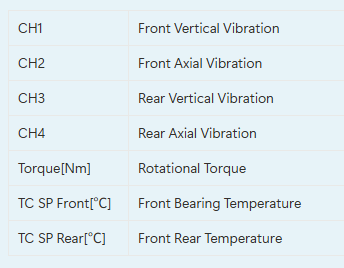

## 고장 판단 기준

---



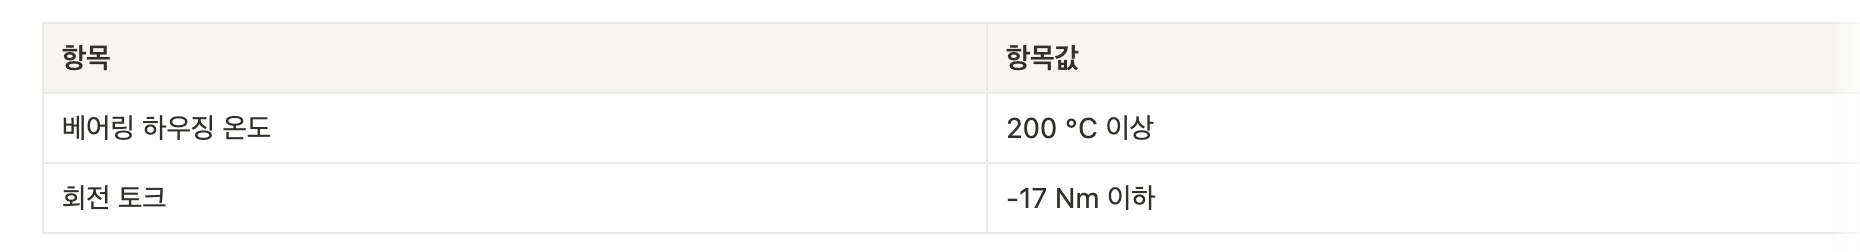

# 데이트 프레임 출력

In [ ]:
# 파일 로드
vib_data, operation_data = load_tdms_file(data_dir)
df = create_time_indexed_dataframe(vib_data, operation_data)
df

,CH1,CH2,CH3,CH4,Torque[Nm],TC SP Front[℃],TC SP Rear[℃]
Time (s),,,,,,,
0.000000,0.541754,-0.227661,-0.532532,0.875950,-6.42555,103.8459,139.8695
0.000039,0.534420,0.455208,1.121502,0.851536,-6.42555,103.8459,139.8695
0.000078,0.104866,1.085415,-0.219097,0.505209,-6.42555,103.8459,139.8695
0.000117,-0.224867,1.135511,-0.816517,0.117903,-6.42555,103.8459,139.8695
0.000156,-0.379467,0.372534,0.468702,-0.021305,-6.42555,103.8459,139.8695
...,...,...,...,...,...,...,...
9.999805,-0.105667,0.229139,-0.493460,1.384535,-6.42555,103.8459,139.8695
9.999844,-0.161791,0.928087,0.431366,1.321735,-6.42555,103.8459,139.8695
9.999883,-0.218277,1.414289,-0.519657,1.092911,-6.42555,103.8459,139.8695


In [ ]:
wav_train1 = pd.read_csv('./wavelet_train1_window sec 0.5s_all_channels.csv')
wav_train1

,Time (s),D1_RMS,D1_Kurtosis,D1_Crest,D1_Skewness,D2_RMS,D2_Kurtosis,D2_Crest,D2_Skewness,D3_RMS,...,D3_Skewness,D4_RMS,D4_Kurtosis,D4_Crest,D4_Skewness,D5_RMS,D5_Kurtosis,D5_Crest,D5_Skewness,Channel
0,0.00,0.313495,0.140251,3.938333,0.026829,0.393942,-0.026031,3.736073,0.003744,0.150558,...,-0.021897,0.148018,-0.144972,2.933272,0.098027,0.089830,0.115411,3.264638,-0.081801,CH1
1,0.25,0.314414,0.060109,3.842231,0.016407,0.398501,0.185098,3.895913,-0.009020,0.148745,...,0.000890,0.147011,-0.039776,2.789296,0.030501,0.089862,0.047686,3.121673,-0.083807,CH1
2,0.50,0.317816,0.023653,3.550192,-0.001418,0.412435,0.090961,3.764291,-0.060043,0.154223,...,0.031490,0.139392,-0.075909,2.904528,0.041030,0.085628,-0.143130,2.752856,0.062349,CH1
3,0.75,0.317539,-0.032590,3.553292,-0.003253,0.406706,-0.059525,3.625097,-0.063132,0.157005,...,0.053592,0.146997,-0.033384,3.537571,-0.065151,0.092606,0.184018,3.631864,0.180330,CH1
4,1.00,0.315664,0.098411,4.031291,-0.010415,0.398547,0.007147,3.699315,-0.057753,0.152525,...,-0.044331,0.150468,-0.253964,2.968431,-0.120788,0.095528,-0.231636,3.122478,0.013842,CH1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14659,55808.50,0.811741,4.513313,10.200014,-0.060376,0.900519,0.709269,5.599823,0.031371,0.949106,...,-0.014523,2.668517,0.224848,3.377996,0.026977,2.627985,0.166724,3.526411,-0.243454,CH4
14660,55808.75,0.810398,4.971901,10.216912,0.017043,0.886773,0.847637,5.686628,0.069710,0.916613,...,-0.060708,2.532278,0.104551,3.377385,0.035951,2.738249,0.049775,3.384409,-0.207029,CH4
14661,55809.00,0.788986,2.851154,7.443532,0.049701,0.859561,0.328456,4.971393,0.003890,0.912872,...,-0.098155,2.632727,0.229439,3.843495,-0.093419,2.730396,-0.109472,2.812589,0.041836,CH4
14662,55809.25,0.792224,1.729665,5.322632,0.012406,0.866450,0.123466,4.179567,-0.037061,0.929080,...,-0.036237,2.659662,0.260944,3.804571,-0.095061,2.838016,0.191776,3.636309,-0.157677,CH4


# Raw 데이터 시각화

In [ ]:
plot_vibration_channels(df)

# RMS 처리 후 시각화(window size = 1000)

In [ ]:
plot_rms_over_time(df)

# RAW data 합쳐서 시각화

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nptdms import TdmsFile
import re
from datetime import datetime, timedelta
import matplotlib as mpl


def visual(a):

      root_folder = a

      # ✅ 7개 전체 채널과 한국어 설명 매핑
      channel_names = {
          "CH1": "전방 수직 진동",
          "CH2": "전방 축 방향 진동",
          "CH3": "후방 수직 진동",
          "CH4": "후방 축 방향 진동",
          "Torque[Nm]": "회전 토크",
          "TC SP Front[℃]": "전방 베어링 온도",
          "TC SP Rear[℃]": "후방 베어링 온도"
      }
      channels = list(channel_names.keys())

      # --- 파일명에서 시작 시간 추출
      def extract_timestamp(filename):
          match = re.search(r"(\d{14})", filename)
          if match:
              return datetime.strptime(match.group(1), "%Y%m%d%H%M%S")
          return None

      # --- TDMS 로딩
      def load_tdms_segments(folder_path):
          segments = []
          timestamps = []

          for fname in sorted(os.listdir(folder_path)):
              if not fname.endswith(".tdms"):
                  continue
              filepath = os.path.join(folder_path, fname)
              tdms_file = TdmsFile.read(filepath)

              group_vib = tdms_file.groups()[0].name
              group_op = tdms_file.groups()[1].name

              vib_data = {ch.name: ch.data for ch in tdms_file[group_vib].channels()}
              op_data = {ch.name.strip(): ch.data[0] for ch in tdms_file[group_op].channels()}

              df = pd.DataFrame(vib_data)
              for k, v in op_data.items():
                  df[k] = v
              segments.append(df)
              timestamps.append(extract_timestamp(fname))

          return segments, timestamps

      # --- 데이터 로딩
      segments, timestamps = load_tdms_segments(root_folder)
      start_time = timestamps[0]
      end_time = timestamps[-1] + timedelta(seconds=10)  # ✅ 마지막 파일 시작 + 10초
      duration = end_time - start_time

      # --- 샘플 인덱스 계산
      segment_lengths = [len(seg) for seg in segments]
      segment_cumsum = np.cumsum([0] + segment_lengths)
      total_length = segment_cumsum[-1]

      # --- 시각화
      plt.figure(figsize=(15, 18))  # 높이 확대

      for i, ch in enumerate(channels, 1):
          plt.subplot(len(channels), 1, i)

          for seg_idx, df in enumerate(segments):
              y = df[ch].values
              x_start = segment_cumsum[seg_idx]
              x_end = segment_cumsum[seg_idx + 1]
              x = np.arange(x_start, x_end)
              plt.plot(x, y, linewidth=0.5, color='gray')

          # 시작/종료 점선
          plt.axvline(x=0, color='r', linestyle='--')
          plt.axvline(x=total_length, color='b', linestyle='--')

          # 시작/종료 시간 라벨
          plt.text(0, plt.ylim()[1]*0.80, f"시작: {start_time.strftime('%Y-%m-%d %H:%M:%S')}", color='r')
          plt.text(total_length, plt.ylim()[1]*0.80, f"종료: {end_time.strftime('%Y-%m-%d %H:%M:%S')}", color='b', ha='right')

          # 측정 시간 출력
          duration_str = f"{duration} ({duration.total_seconds():.1f}초)"
          plt.text(total_length / 2, plt.ylim()[1]*0.78, f"측정 시간: {duration_str}", color='blue', ha='center', fontsize=10)

          plt.title(channel_names[ch])
          plt.xlabel("샘플 인덱스")
          plt.ylabel("진폭")
          plt.grid(True)

      plt.tight_layout()
      plt.show()

# 합쳐서 시각화

<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-56d64a20c42c>:100: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipyt

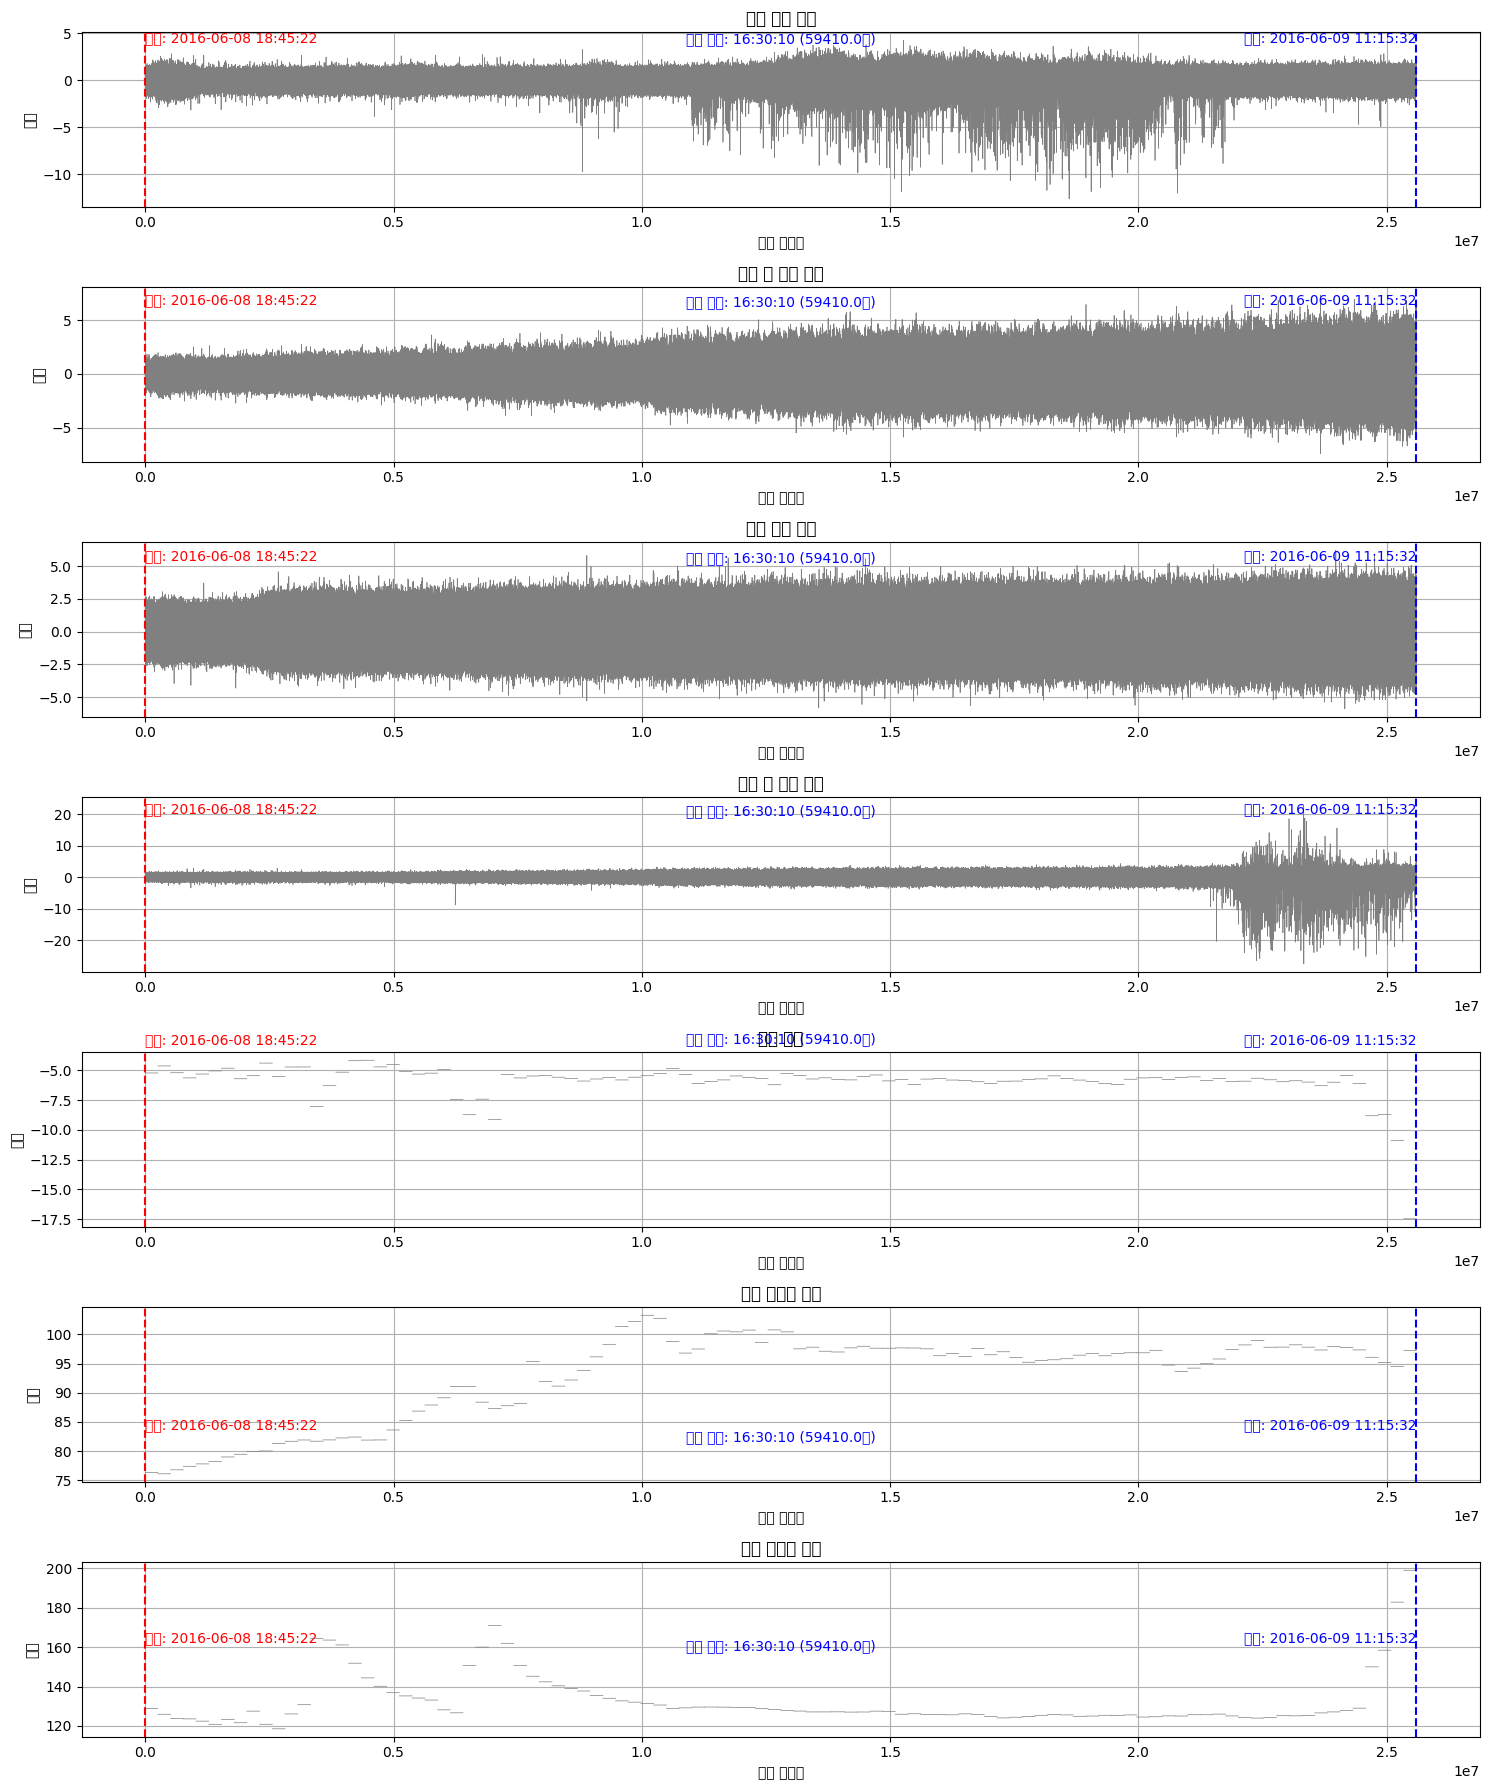

In [ ]:
# --- 설정
# root_Folder에 있는 train 1 ~ 8 다 시각화해보기
root_folder = "data/Train Set/Train8"
visual(root_folder)